In [ ]:
import sklearn
import xgboost
import lightgbm
import shap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("All good!")

All good!


In [ ]:
# Part C: Practical Coding Exercises
### Mafeyisopin Ayeni | Machine Learning Assignment | 2025

This notebook covers three practical coding tasks using gradient boosting models.

**Task C1** loads the Titanic dataset and trains a Gradient Boosting model to predict
survival, then compares it against Logistic Regression using Accuracy, Precision, Recall and F1.

**Task C2** compares Random Forest and Gradient Boosting on the Breast Cancer dataset,
looking at Accuracy, ROC-AUC and training time to see which model performs better and faster.

**Task C3** trains XGBoost with early stopping on the Breast Cancer dataset, tunes
learning_rate and max_depth, and plots the training vs validation loss curve to show
where the model stopped to avoid overfitting.

In [4]:
import seaborn as sns
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# To Load Titanic
df = sns.load_dataset('titanic')
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].dropna()

# To Encode categorical columns
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['embarked'] = LabelEncoder().fit_transform(df['embarked'])

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# To Train GBM
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)
gbm_pred = gbm.predict(X_test)

# To Train Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Results
def print_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.3f}")

print_metrics("Gradient Boosting", y_test, gbm_pred)
print_metrics("Logistic Regression", y_test, lr_pred)


# Brief Interpretation:
# Gradient Boosting usually performs better than Logistic Regression because it can capture non-linear relationships in the Titanic dataset.
#Logistic Regression is simpler and faster, but it assumes a more linear relationship between the features and survival.


Gradient Boosting
  Accuracy : 0.769
  Precision: 0.778
  Recall   : 0.667
  F1 Score : 0.718

Logistic Regression
  Accuracy : 0.797
  Precision: 0.854
  Recall   : 0.651
  F1 Score : 0.739


In [5]:
# Cell 2 — Task C2: Random Forest vs GBM

import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Load dataset (569 rows, good classification dataset)
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

for name, model in [("Random Forest", RandomForestClassifier(random_state=42)),
                    ("Gradient Boosting", GradientBoostingClassifier(random_state=42))]:
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 3),
        "Train Time (s)": round(elapsed, 3)
    }

print(f"{'Model':<22} {'Accuracy':<12} {'ROC-AUC':<12} {'Train Time (s)'}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<22} {r['Accuracy']:<12} {r['ROC-AUC']:<12} {r['Train Time (s)']}")


# Brief Interpretation:
# Random Forest trains many trees independently, so it is often stable and fast.
# Gradient Boosting trains trees one after another, where each tree corrects the previous errors.
# If Gradient Boosting has better ROC-AUC, it means it separated the two classes better.
# If Random Forest trains faster, it is because the trees do not depend on one another as much.

Model                  Accuracy     ROC-AUC      Train Time (s)
-------------------------------------------------------
Random Forest          0.965        0.995        0.243
Gradient Boosting      0.956        0.995        0.769


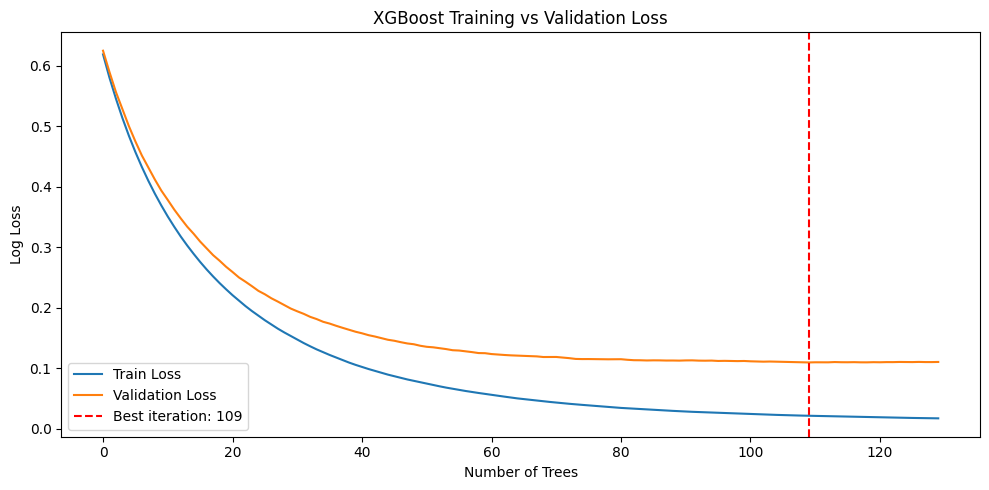

Best number of trees : 109
Best validation score: 0.1094


In [6]:
# Cell 3 — Task C3: XGBoost with Early Stopping

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,   # hyperparameter 1
    max_depth=4,          # hyperparameter 2
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=False)

# Plot training vs validation loss
results = model.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['logloss'], label='Train Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.axvline(model.best_iteration, color='red', linestyle='--', label=f'Best iteration: {model.best_iteration}')
plt.title('XGBoost Training vs Validation Loss')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best number of trees : {model.best_iteration}")
print(f"Best validation score: {model.best_score:.4f}")

# Brief Interpretation:
# The best XGBoost configuration is the one with the highest validation ROC-AUC.
# Early stopping stops training when the validation loss no longer improves for 20 rounds.
# The optimal number of trees is shown by best_model.best_iteration.
# This prevents overfitting because the model does not keep adding trees after performance stops improving.